# Ridge Regression

Ridge Regression is a regularized version of Linear Regression that prevents overfitting by adding a penalty term to the loss function.

## Import libraries and dataset


In [ ]:
#importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [ ]:
#Importing the dataset
df = pd.read_csv('/content/Advertising (1).csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Define variables and split into train and test set


In [ ]:
X = df[['TV','Radio','Newspaper']] #Features(Independent variables)
y = df['Sales'] #Target(Dependent variable)

In [ ]:
# 70% train, 30% temp
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split temp into validation and test (15% each)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

## Apply Ridge Regression

In [ ]:
ridge_model = Ridge(alpha=10)
ridge_model.fit(x_train, y_train)

Ridge(alpha=10)

In [ ]:
print(f"Aplha = {ridge_model.alpha}")
print(pd.Series(ridge_model.coef_, index=X.columns))

Aplha = 10
TV           0.044060
Radio        0.199212
Newspaper    0.006899
dtype: float64


Plot coefficients vs column names

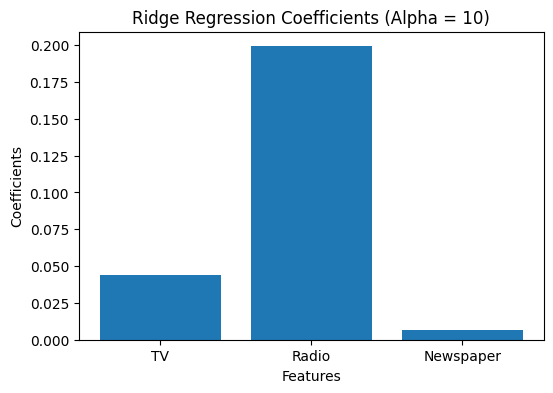

In [ ]:
coefficients = ridge_model.coef_ #Store coefficients

plt.figure(figsize=(6,4))
plt.bar(X.columns, coefficients)
plt.xlabel('Features')
plt.ylabel('Coefficients')
plt.title(f"Ridge Regression Coefficients (Alpha = {ridge_model.alpha})")
plt.show()

Alpha = 0.0100 | Coefficients = [0.04405928 0.19928742 0.00688247]
Alpha = 0.0126 | Coefficients = [0.04405928 0.1992874  0.00688247]
Alpha = 0.0160 | Coefficients = [0.04405928 0.19928738 0.00688248]
Alpha = 0.0202 | Coefficients = [0.04405928 0.19928734 0.00688249]
Alpha = 0.0256 | Coefficients = [0.04405928 0.1992873  0.0068825 ]
Alpha = 0.0324 | Coefficients = [0.04405928 0.19928725 0.00688251]
Alpha = 0.0409 | Coefficients = [0.04405928 0.19928719 0.00688252]
Alpha = 0.0518 | Coefficients = [0.04405928 0.19928711 0.00688254]
Alpha = 0.0655 | Coefficients = [0.04405928 0.199287   0.00688256]
Alpha = 0.0829 | Coefficients = [0.04405928 0.19928687 0.00688259]
Alpha = 0.1048 | Coefficients = [0.04405928 0.19928671 0.00688263]
Alpha = 0.1326 | Coefficients = [0.04405928 0.1992865  0.00688268]
Alpha = 0.1677 | Coefficients = [0.04405929 0.19928624 0.00688274]
Alpha = 0.2121 | Coefficients = [0.04405929 0.1992859  0.00688281]
Alpha = 0.2683 | Coefficients = [0.04405929 0.19928548 0.00688

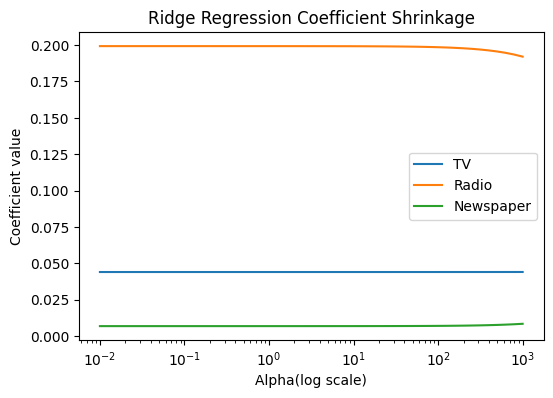

In [ ]:
#Generate alpha values on log scale
alphas = np.logspace(-2, 3, 50)

#Store coefficients
coefficients_path = []

for alpha_value in alphas:
  ridge_model = Ridge(alpha=alpha_value)
  ridge_model.fit(x_train, y_train)
  coefficients_path.append(ridge_model.coef_)

  print(f"Alpha = {alpha_value:.4f} | Coefficients = {ridge_model.coef_}") #Printing coefficients

coefficients_path = np.array(coefficients_path) #Convert to numpy array

#plot
plt.figure(figsize=(6,4))
plt.plot(alphas, coefficients_path)
plt.xscale('log')
plt.xlabel('Alpha(log scale)')
plt.ylabel('Coefficient value')
plt.title('Ridge Regression Coefficient Shrinkage')
plt.legend(X.columns)

In [ ]:
r2_train = ridge_model.score(x_train, y_train)
r2_val = ridge_model.score(x_val, y_val)
r2_test = ridge_model.score(x_test, y_test)

print(f"R2 Score (Train): {r2_train:.4f}")
print(f"R2 Score (Validation): {r2_val:.4f}")
print(f"R2 Score (Test): {r2_test:.4f}")

R2 Score (Train): 0.9051
R2 Score (Validation): 0.9168
R2 Score (Test): 0.7999
